# Анализ эксперимента про доверие к рекомендациям ИИ в моральных дилеммах


## 1. Импорт библиотек и загрузка данных


In [1]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_rel, mannwhitneyu, wilcoxon, pearsonr, spearmanr
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')


In [2]:
df = pd.read_excel('coursework_data.xlsx')

print('Размер исходной таблицы:', df.shape)
df.head()


Размер исходной таблицы: (165, 78)


,respondentId,startedAt,finishedAt,groupNumber,patternIndex,advisorType,congruentEverydayIndex,congruentClassicIndex,gender,age,education_level,education_profile,employment_status,ai_usage,ai_trust,ai_agent,ai_agent_other,dilemma_1_id,dilemma_1_initialChoice,dilemma_1_initialConfidence,dilemma_1_advisorRecommendedOption,dilemma_1_advisorCongruentWithInitialChoice,dilemma_1_advisorOppositeToInitialChoice,dilemma_1_finalChoice,dilemma_1_finalConfidence,dilemma_1_changedChoiceAfterAdvice,dilemma_1_timestamp,dilemma_2_id,dilemma_2_initialChoice,dilemma_2_initialConfidence,dilemma_2_advisorRecommendedOption,dilemma_2_advisorCongruentWithInitialChoice,dilemma_2_advisorOppositeToInitialChoice,dilemma_2_finalChoice,dilemma_2_finalConfidence,dilemma_2_changedChoiceAfterAdvice,dilemma_2_timestamp,dilemma_3_id,dilemma_3_initialChoice,dilemma_3_initialConfidence,dilemma_3_advisorRecommendedOption,dilemma_3_advisorCongruentWithInitialChoice,dilemma_3_advisorOppositeToInitialChoice,dilemma_3_finalChoice,dilemma_3_finalConfidence,dilemma_3_changedChoiceAfterAdvice,dilemma_3_timestamp,dilemma_4_id,dilemma_4_initialChoice,dilemma_4_initialConfidence,dilemma_4_advisorRecommendedOption,dilemma_4_advisorCongruentWithInitialChoice,dilemma_4_advisorOppositeToInitialChoice,dilemma_4_finalChoice,dilemma_4_finalConfidence,dilemma_4_changedChoiceAfterAdvice,dilemma_4_timestamp,dilemma_5_id,dilemma_5_initialChoice,dilemma_5_initialConfidence,dilemma_5_advisorRecommendedOption,dilemma_5_advisorCongruentWithInitialChoice,dilemma_5_advisorOppositeToInitialChoice,dilemma_5_finalChoice,dilemma_5_finalConfidence,dilemma_5_changedChoiceAfterAdvice,dilemma_5_timestamp,dilemma_6_id,dilemma_6_initialChoice,dilemma_6_initialConfidence,dilemma_6_advisorRecommendedOption,dilemma_6_advisorCongruentWithInitialChoice,dilemma_6_advisorOppositeToInitialChoice,dilemma_6_finalChoice,dilemma_6_finalConfidence,dilemma_6_changedChoiceAfterAdvice,dilemma_6_timestamp,serverReceivedAt
0,R-1776795862866-69848,2026-04-21T18:24:22.866Z,2026-04-21T18:33:12.784Z,3,3,ai,1,3,Женский,19,Бакалавриат / специалитет,Экономика/бизнес/менеджмент,Учусь,Примерно раз в день,5,Grok,NaN,cashier,B,5,B,True,False,B,5,False,2026-04-21T18:33:12.784Z,bus,B,5,A,False,True,B,4,False,2026-04-21T18:33:12.784Z,wardrobe,B,5,A,False,True,B,5,False,2026-04-21T18:33:12.784Z,restaurant,B,4,A,False,True,B,2,False,2026-04-21T18:33:12.784Z,tram,B,7,A,False,True,B,7,False,2026-04-21T18:33:12.784Z,zoo,B,3,B,True,False,B,5,False,2026-04-21T18:33:12.784Z,2026-04-21T18:33:15.318Z
1,R-1776796597710-86018,2026-04-21T18:36:37.710Z,2026-04-21T18:40:57.589Z,2,2,ai,1,2,Мужской,21,Бакалавриат / специалитет,Технические/инженерные,Учусь и работаю,Несколько раз в день,4,Gemini,NaN,cashier,A,6,A,True,False,A,6,False,2026-04-21T18:40:57.590Z,bus,A,4,B,False,True,A,4,False,2026-04-21T18:40:57.590Z,wardrobe,A,5,B,False,True,A,5,False,2026-04-21T18:40:57.590Z,restaurant,B,7,A,False,True,B,7,False,2026-04-21T18:40:57.590Z,tram,B,7,B,True,False,B,7,False,2026-04-21T18:40:57.590Z,zoo,B,7,A,False,True,B,7,False,2026-04-21T18:40:57.590Z,2026-04-21T18:41:03.222Z
2,R-1776796667917-4166,2026-04-21T18:37:47.917Z,2026-04-21T18:42:24.445Z,12,3,human,1,3,Женский,18,Бакалавриат / специалитет,Социальные науки,Учусь,Несколько раз в день,5,ChatGPT,NaN,cashier,A,6,A,True,False,A,6,False,2026-04-21T18:42:24.445Z,bus,A,7,B,False,True,A,6,False,2026-04-21T18:42:24.446Z,wardrobe,B,6,A,False,True,B,6,False,2026-04-21T18:42:24.446Z,restaurant,B,7,A,False,True,B,7,False,2026-04-21T18:42:24.446Z,tram,B,7,A,False,True,B,7,False,2026-04-21T18:42:24.446Z,zoo,B,6,B,True,False,B,6,False,2026-04-21T18:42:24.446Z,2026-04-21T18:42:26.285Z
3,R-1776797288841-47016,2026-04-21T18:48:08.841Z,2026-04-21T18:53:06.993Z,3,3,ai,1,3,Женский,18,Бакалавриат / специалитет,Психология/Философия,Учусь и работаю,Несколько раз в день,5,ChatGPT,NaN,cashier,B,2,B,True,False,B,3,False,2026-04-21T18:53:06.993Z,bus,B,2,A,False,True,A,2,True,2026-04-21T18:53:06.993Z,wardrobe,B,4,A,False,True

## 2. Проверка качества данных

В этом блоке проверяются базовые характеристики данных, которые используются в описании выборки и при принятии решения об исключении респондентов.


In [3]:
# Проверка возраста
df['age'].describe()


count   165.000
mean     21.327
std       5.798
min      18.000
25%      19.000
50%      19.000
75%      21.000
max      53.000
Name: age, dtype: float64

In [4]:
# Время прохождения исследования
df['startedAt'] = pd.to_datetime(df['startedAt'])
df['finishedAt'] = pd.to_datetime(df['finishedAt'])
df['duration_sec'] = (df['finishedAt'] - df['startedAt']).dt.total_seconds()
df['duration_min'] = df['duration_sec'] / 60

display(df['duration_sec'].describe())
display(df['duration_sec'].quantile([.01, .05, .10, .25, .50, .75, .90, .95, .99]))


count      165.000
mean      1448.806
std      11272.090
min        159.237
25%        251.209
50%        311.243
75%        404.231
max     142689.648
Name: duration_sec, dtype: float64

0.010     166.541
0.050     183.656
0.100     199.221
0.250     251.209
0.500     311.243
0.750     404.231
0.900     567.399
0.950     961.599
0.990   13383.334
Name: duration_sec, dtype: float64

## 3. Подготовка переменных

Для каждой из шести дилемм создаются единообразные переменные: изменение решения, совпадение рекомендации с первоначальным выбором, несовпадение рекомендации и изменение уверенности.


In [5]:
DILEMMAS = [1, 2, 3, 4, 5, 6]
everyday = [1, 2, 3]
classic = [4, 5, 6]

# 1–3 — бытовые дилеммы, 4–6 — классические
dilemma_types = {
    1: 'Бытовая',
    2: 'Бытовая',
    3: 'Бытовая',
    4: 'Классическая',
    5: 'Классическая',
    6: 'Классическая'
}

dilemma_names = {
    1: 'Возврат сдачи',
    2: 'Помощь прохожему',
    3: 'Верность обещанию',
    4: 'Спасение семьи',
    5: 'Трамвайная дилемма',
    6: 'Жертва сотрудника'
}

choice_before_cols = [f'dilemma_{i}_initialChoice' for i in DILEMMAS]          # выбор до получения рекомендации
choice_after_cols = [f'dilemma_{i}_finalChoice' for i in DILEMMAS]             # выбор после получения рекомендации
conf_before_cols = [f'dilemma_{i}_initialConfidence' for i in DILEMMAS]        # уверенность до получения рекомендации
conf_after_cols = [f'dilemma_{i}_finalConfidence' for i in DILEMMAS]           # уверенность после получения рекомендации
recommendation_cols = [f'dilemma_{i}_advisorRecommendedOption' for i in DILEMMAS]      # вариант, рекомендованный советчиком
congruent_cols = [f'dilemma_{i}_advisorCongruentWithInitialChoice' for i in DILEMMAS]  # совпадение рекомендации с первоначальным выбором
changed_cols_raw = [f'dilemma_{i}_changedChoiceAfterAdvice' for i in DILEMMAS]         # факт изменения решения после рекомендации


In [6]:
for i in DILEMMAS:
    df[f'd{i}_changed'] = df[f'dilemma_{i}_changedChoiceAfterAdvice'].astype(int)                # изменение решения после рекомендации
    df[f'd{i}_congruent'] = df[f'dilemma_{i}_advisorCongruentWithInitialChoice'].astype(int)     # рекомендация совпала с первоначальным выбором
    df[f'd{i}_disagree'] = 1 - df[f'd{i}_congruent']                                             # рекомендация противоречила первоначальному выбору
    df[f'd{i}_delta_conf'] = df[f'dilemma_{i}_finalConfidence'] - df[f'dilemma_{i}_initialConfidence']  # изменение уверенности

change_cols = [f'd{i}_changed' for i in DILEMMAS]
congruent_binary_cols = [f'd{i}_congruent' for i in DILEMMAS]
disagree_cols = [f'd{i}_disagree' for i in DILEMMAS]
delta_conf_cols = [f'd{i}_delta_conf' for i in DILEMMAS]

df['n_congruent_dilemmas'] = df[congruent_binary_cols].sum(axis=1)
df['n_disagree_dilemmas'] = df[disagree_cols].sum(axis=1)

df[['n_congruent_dilemmas', 'n_disagree_dilemmas']].describe()


,n_congruent_dilemmas,n_disagree_dilemmas
count,165.000,165.000
mean,2.000,4.000
std,0.000,0.000
min,2.000,4.000
25%,2.000,4.000
50%,2.000,4.000
75%,2.000,4.000
max,2.000,4.000


In [7]:
# Показатели изменения решения
# Основной показатель: доля измененных решений в дилеммах, где рекомендация противоречила первоначальному выбору.

df['changes_total_disagree'] = 0
for i in DILEMMAS:
    df['changes_total_disagree'] += df[f'd{i}_changed'] * df[f'd{i}_disagree']

df['changes_mean_disagree'] = df['changes_total_disagree'] / df['n_disagree_dilemmas']

# Бытовые и классические дилеммы отдельно
df['n_disagree_everyday'] = df[[f'd{i}_disagree' for i in everyday]].sum(axis=1)
df['changes_total_disagree_everyday'] = sum(df[f'd{i}_changed'] * df[f'd{i}_disagree'] for i in everyday)
df['changes_mean_disagree_everyday'] = df['changes_total_disagree_everyday'] / df['n_disagree_everyday']

df['n_disagree_classic'] = df[[f'd{i}_disagree' for i in classic]].sum(axis=1)
df['changes_total_disagree_classic'] = sum(df[f'd{i}_changed'] * df[f'd{i}_disagree'] for i in classic)
df['changes_mean_disagree_classic'] = df['changes_total_disagree_classic'] / df['n_disagree_classic']

df[[
    'changes_total_disagree',
    'changes_mean_disagree',
    'changes_mean_disagree_everyday',
    'changes_mean_disagree_classic'
]].describe()


,changes_total_disagree,changes_mean_disagree,changes_mean_disagree_everyday,changes_mean_disagree_classic
count,165.000,165.000,165.000,165.000
mean,0.230,0.058,0.070,0.045
std,0.489,0.122,0.182,0.154
min,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.000,0.000
max,2.000,0.500,1.000,1.000


In [8]:
# Показатели уверенности

df['conf_before_mean_all'] = df[conf_before_cols].mean(axis=1)
df['conf_after_mean_all'] = df[conf_after_cols].mean(axis=1)
df['delta_conf_mean_all'] = df[delta_conf_cols].mean(axis=1)

# Средняя исходная уверенность в дилеммах с несогласующейся рекомендацией
conf_disagree_sum = 0
for i in DILEMMAS:
    conf_disagree_sum += df[f'dilemma_{i}_initialConfidence'] * df[f'd{i}_disagree']

df['conf_before_disagree_mean'] = conf_disagree_sum / df['n_disagree_dilemmas']

# Уверенность по бытовым и классическим дилеммам
df['conf_before_everyday'] = df[[f'dilemma_{i}_initialConfidence' for i in everyday]].mean(axis=1)
df['conf_after_everyday'] = df[[f'dilemma_{i}_finalConfidence' for i in everyday]].mean(axis=1)
df['conf_before_classic'] = df[[f'dilemma_{i}_initialConfidence' for i in classic]].mean(axis=1)
df['conf_after_classic'] = df[[f'dilemma_{i}_finalConfidence' for i in classic]].mean(axis=1)

# Изменение уверенности в согласующихся и несогласующихся дилеммах
delta_congruent_sum = 0
delta_disagree_sum = 0
for i in DILEMMAS:
    delta_congruent_sum += df[f'd{i}_delta_conf'] * df[f'd{i}_congruent']
    delta_disagree_sum += df[f'd{i}_delta_conf'] * df[f'd{i}_disagree']

df['delta_conf_congruent_mean'] = delta_congruent_sum / df['n_congruent_dilemmas']
df['delta_conf_disagree_mean'] = delta_disagree_sum / df['n_disagree_dilemmas']
df['delta_conf_congruent_minus_disagree'] = df['delta_conf_congruent_mean'] - df['delta_conf_disagree_mean']

df[[
    'conf_before_mean_all',
    'conf_after_mean_all',
    'delta_conf_mean_all',
    'delta_conf_congruent_mean',
    'delta_conf_disagree_mean',
    'conf_before_disagree_mean'
]].describe()


,conf_before_mean_all,conf_after_mean_all,delta_conf_mean_all,delta_conf_congruent_mean,delta_conf_disagree_mean,conf_before_disagree_mean
count,165.000,165.000,165.000,165.000,165.000,165.000
mean,5.873,5.898,0.025,0.155,-0.039,5.868
std,0.831,0.860,0.298,0.433,0.396,0.866
min,3.167,2.500,-1.333,-1.500,-2.250,3.250
25%,5.333,5.333,-0.167,0.000,-0.250,5.250
50%,6.000,6.000,0.000,0.000,0.000,6.000
75%,6.500,6.500,0.167,0.000,0.000,6.500
max,7.000,7.000,1.167,2.000,1.250,7.000


## 3.1. Предварительный анализ стимульного материала


In [9]:
dilemma_summary = []

for i in DILEMMAS:
    mask_disagree = df[f'd{i}_disagree'] == 1
    changed_disagree = df.loc[mask_disagree, f'd{i}_changed'].mean() if mask_disagree.sum() > 0 else np.nan

    dilemma_summary.append({
        'Дилемма': i,
        'Название': dilemma_names[i],
        'Тип': dilemma_types[i],
        'Выбор варианта действия, %': df[f'dilemma_{i}_initialChoice'].eq('A').mean() * 100,
        'Выбор варианта бездействия, %': df[f'dilemma_{i}_initialChoice'].eq('B').mean() * 100,
        'Уверенность до совета (M)': df[f'dilemma_{i}_initialConfidence'].mean(),
        'Уверенность до совета (SD)': df[f'dilemma_{i}_initialConfidence'].std(),
        'Изменили решение, %': changed_disagree * 100
    })

dilemma_summary = pd.DataFrame(dilemma_summary).round(3)
dilemma_summary


,Дилемма,Название,Тип,"Выбор варианта действия, %","Выбор варианта бездействия, %",Уверенность до совета (M),Уверенность до совета (SD),"Изменили решение, %"
0,1,Возврат сдачи,Бытовая,88.485,11.515,6.206,1.156,2.083
1,2,Помощь прохожему,Бытовая,43.636,56.364,5.224,1.429,11.607
2,3,Верность обещанию,Бытовая,32.121,67.879,5.697,1.345,6.557
3,4,Спасение семьи,Классическая,9.091,90.909,5.915,1.309,6.364
4,5,Трамвайная дилемма,Классическая,7.879,92.121,6.188,1.314,0.000
5,6,Жертва сотрудника,Классическая,13.939,86.061,6.006,1.484,7.273


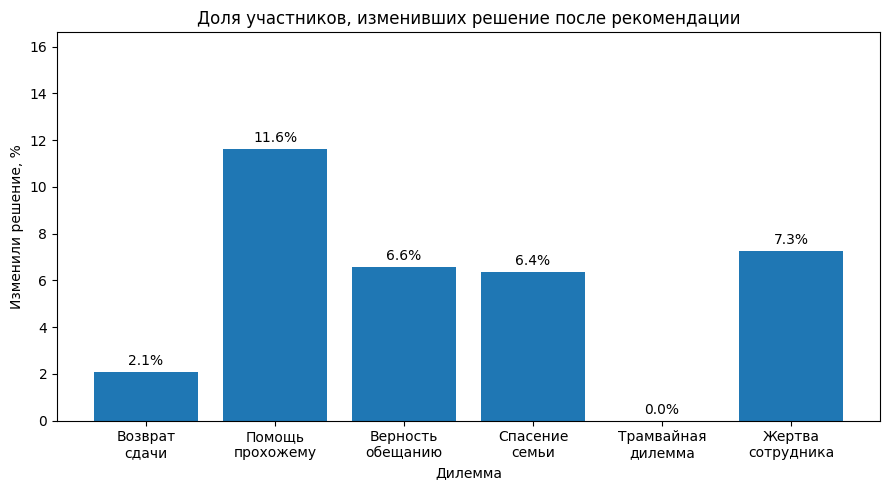

In [10]:
plot_names = [
    'Возврат\nсдачи',
    'Помощь\nпрохожему',
    'Верность\nобещанию',
    'Спасение\nсемьи',
    'Трамвайная\nдилемма',
    'Жертва\nсотрудника'
]

changed_percent = dilemma_summary['Изменили решение, %']

plt.figure(figsize=(9, 5))
plt.bar(plot_names, changed_percent)
plt.ylabel('Изменили решение, %')
plt.xlabel('Дилемма')
plt.title('Доля участников, изменивших решение после рекомендации')
plt.ylim(0, max(changed_percent) + 5)

for i, value in enumerate(changed_percent):
    plt.text(i, value + 0.3, f'{value:.1f}%', ha='center')

plt.tight_layout()
plt.show()


## 3.2. Влияние рекомендаций на изменение моральных решений


### 3.2.1. Различия между рекомендациями ИИ и эксперта


In [11]:
# Средняя доля измененных решений в зависимости от типа советчика
if 'participant_id' not in df.columns:
    df['participant_id'] = np.arange(len(df))

advisor_change = df.groupby('advisorType').agg(
    n=('participant_id', 'count'),
    mean_change_percent=('changes_mean_disagree', lambda x: x.mean() * 100)
).reset_index()

advisor_change['advisor_label'] = advisor_change['advisorType'].map({
    'ai': 'Искусственный интеллект',
    'human': 'Эксперт-философ'
})

advisor_change[['advisor_label', 'n', 'mean_change_percent']].round(3)


,advisor_label,n,mean_change_percent
0,Искусственный интеллект,84,5.060
1,Эксперт-философ,81,6.481


In [12]:
ai = df.loc[df['advisorType'] == 'ai', 'changes_mean_disagree'].dropna()
human = df.loc[df['advisorType'] == 'human', 'changes_mean_disagree'].dropna()

u, p = mannwhitneyu(ai, human, alternative='two-sided')

print('Mann–Whitney U')
print(f'U = {u:.1f}')
print(f'p = {p:.3f}')
print()
print('Медианы:')
print(f'AI = {ai.median():.3f}')
print(f'Expert = {human.median():.3f}')


Mann–Whitney U
U = 3249.0
p = 0.475

Медианы:
AI = 0.000
Expert = 0.000


### 3.2.2. Бытовые и классические дилеммы


In [13]:
tmp = df[['changes_mean_disagree_everyday', 'changes_mean_disagree_classic']].dropna()

w, p = wilcoxon(
    tmp['changes_mean_disagree_everyday'],
    tmp['changes_mean_disagree_classic'],
    alternative='two-sided'
)

print('Wilcoxon signed-rank')
print(f'W = {w:.1f}')
print(f'p = {p:.3f}')
print()
print('Средние доли измененных решений:')
print(f'Бытовые дилеммы = {tmp["changes_mean_disagree_everyday"].mean() * 100:.1f}%')
print(f'Классические дилеммы = {tmp["changes_mean_disagree_classic"].mean() * 100:.1f}%')


Wilcoxon signed-rank
W = 174.5
p = 0.184

Средние доли измененных решений:
Бытовые дилеммы = 7.0%
Классические дилеммы = 4.5%


### 3.2.3. Роль исходной уверенности


In [14]:
rho, p = spearmanr(
    df['conf_before_disagree_mean'],
    df['changes_mean_disagree'],
    nan_policy='omit'
)

print(f'Spearman rho = {rho:.3f}')
print(f'p = {p:.4f}')


Spearman rho = -0.300
p = 0.0001


### 3.2.4. Регрессионный анализ изменения решений


In [15]:
def tidy_ols(model, model_name='model'):
    """Таблица коэффициентов OLS-модели."""
    out = pd.DataFrame({
        'term': model.params.index,
        'coef': model.params.values,
        'se': model.bse.values,
        't': model.tvalues.values,
        'p': model.pvalues.values,
        'ci_low': model.conf_int()[0].values,
        'ci_high': model.conf_int()[1].values,
    })
    out.insert(0, 'model', model_name)
    return out


def model_info(model, model_name='model'):
    """Краткая информация о модели."""
    return pd.DataFrame({
        'model': [model_name],
        'nobs': [model.nobs],
        'F': [getattr(model, 'fvalue', np.nan)],
        'p(F)': [getattr(model, 'f_pvalue', np.nan)],
        'R²': [getattr(model, 'rsquared', np.nan)],
        'Adj. R²': [getattr(model, 'rsquared_adj', np.nan)]
    })


In [16]:
change_m1 = smf.ols(
    'changes_mean_disagree ~ C(advisorType)',
    data=df
).fit(cov_type='HC3')

change_m2 = smf.ols(
    'changes_mean_disagree ~ C(advisorType) + conf_before_disagree_mean',
    data=df
).fit(cov_type='HC3')

change_m3 = smf.ols(
    'changes_mean_disagree ~ C(advisorType) + conf_before_disagree_mean + ai_trust + C(ai_usage)',
    data=df
).fit(cov_type='HC3')

change_m4 = smf.ols(
    'changes_mean_disagree ~ C(advisorType) + conf_before_disagree_mean + ai_trust + age + C(gender) + C(education_level) + C(ai_usage)',
    data=df
).fit(cov_type='HC3')

change_m5 = smf.ols(
    'changes_mean_disagree ~ C(advisorType) * ai_trust + conf_before_disagree_mean + age + C(gender) + C(education_level) + C(ai_usage)',
    data=df
).fit(cov_type='HC3')

change_results = pd.concat([
    tidy_ols(change_m1, 'M1'),
    tidy_ols(change_m2, 'M2'),
    tidy_ols(change_m3, 'M3'),
    tidy_ols(change_m4, 'M4'),
    tidy_ols(change_m5, 'M5')
], ignore_index=True)

change_results


,model,term,coef,se,t,p,ci_low,ci_high
0,M1,Intercept,0.051,0.013,4.009,0.000,0.026,0.075
1,M1,C(advisorType)[T.human],0.014,0.019,0.739,0.460,-0.023,0.052
2,M2,Intercept,0.318,0.080,3.996,0.000,0.162,0.474
3,M2,C(advisorType)[T.human],0.021,0.018,1.123,0.261,-0.015,0.056
4,M2,conf_before_disagree_mean,-0.046,0.013,-3.660,0.000,-0.071,-0.021
5,M3,Intercept,0.270,0.080,3.378,0.001,0.113,0.426
6,M3,C(advisorType)[T.human],0.020,0.019,1.077,0.282,-0.016,0.056
7,M3,C(ai_usage)[T.Несколько раз в неделю],0.034,0.033,1.012,0.312,-0.031,0.099
8,M3,C(ai_usage)[T.Практически не использую],-0.006,0.032,-0.184,0.854,-0.069,0.057
9,M3,C(ai_usage)[T.Примерно раз в день],-0.033,0.023,-1.435,0.151,-0.077,0.012


In [17]:
# Коэффициенты детерминации моделей изменения решения
change_model_info = pd.concat([
    model_info(change_m1, 'M1'),
    model_info(change_m2, 'M2'),
    model_info(change_m3, 'M3'),
    model_info(change_m4, 'M4'),
    model_info(change_m5, 'M5')
], ignore_index=True)

change_model_info.round(3)


,model,nobs,F,p(F),R²,Adj. R²
0,M1,165.000,0.547,0.461,0.003,-0.003
1,M2,165.000,7.191,0.001,0.109,0.098
2,M3,165.000,3.188,0.003,0.148,0.110
3,M4,165.000,1.625,0.073,0.158,0.073
4,M5,165.000,1.458,0.123,0.160,0.069


In [18]:
# Регрессионная выдача модели M5
print(change_m5.summary())

                              OLS Regression Results                             
Dep. Variable:     changes_mean_disagree   R-squared:                       0.160
Model:                               OLS   Adj. R-squared:                  0.069
Method:                    Least Squares   F-statistic:                     1.458
Date:                   Mon, 29 Jun 2026   Prob (F-statistic):              0.123
Time:                           15:31:23   Log-Likelihood:                 127.44
No. Observations:                    165   AIC:                            -220.9
Df Residuals:                        148   BIC:                            -168.1
Df Model:                             16                                         
Covariance Type:                     HC3                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [19]:
# Сокращенная модель AM
change_am = smf.ols(
    'changes_mean_disagree ~ C(advisorType) + conf_before_disagree_mean + ai_trust + age',
    data=df
).fit(cov_type='HC3')

tidy_ols(change_am, 'AM')


,model,term,coef,se,t,p,ci_low,ci_high
0,AM,Intercept,0.269,0.079,3.419,0.001,0.115,0.423
1,AM,C(advisorType)[T.human],0.019,0.018,1.022,0.307,-0.017,0.055
2,AM,conf_before_disagree_mean,-0.047,0.013,-3.690,0.000,-0.072,-0.022
3,AM,ai_trust,0.011,0.009,1.327,0.185,-0.005,0.028
4,AM,age,0.000,0.001,0.280,0.780,-0.002,0.003


In [20]:
model_info(change_am, 'AM').round(3)


,model,nobs,F,p(F),R²,Adj. R²
0,AM,165.000,3.641,0.007,0.121,0.099


In [21]:
# Регрессионная выдача модели AM
print(change_am.summary())

                              OLS Regression Results                             
Dep. Variable:     changes_mean_disagree   R-squared:                       0.121
Model:                               OLS   Adj. R-squared:                  0.099
Method:                    Least Squares   F-statistic:                     3.641
Date:                   Mon, 29 Jun 2026   Prob (F-statistic):            0.00721
Time:                           15:31:23   Log-Likelihood:                 123.77
No. Observations:                    165   AIC:                            -237.5
Df Residuals:                        160   BIC:                            -222.0
Df Model:                              4                                         
Covariance Type:                     HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

## 3.3. Влияние рекомендаций на субъективную уверенность


### 3.3.1. Влияние согласия рекомендации


In [22]:
# Описательная статистика изменения уверенности при согласующейся и несогласующейся рекомендации
desc_conf_agreement = df[['delta_conf_congruent_mean', 'delta_conf_disagree_mean']].describe()
desc_conf_agreement


,delta_conf_congruent_mean,delta_conf_disagree_mean
count,165.000,165.000
mean,0.155,-0.039
std,0.433,0.396
min,-1.500,-2.250
25%,0.000,-0.250
50%,0.000,0.000
75%,0.000,0.000
max,2.000,1.250


In [23]:
t_stat, p_value = ttest_rel(
    df['delta_conf_congruent_mean'],
    df['delta_conf_disagree_mean'],
    nan_policy='omit'
)

paired_diff = df['delta_conf_congruent_mean'] - df['delta_conf_disagree_mean']
cohens_d = paired_diff.mean() / paired_diff.std(ddof=1)

print(f't = {t_stat:.3f}')
print(f'p = {p_value:.5f}')
print(f"Cohen's d = {cohens_d:.3f}")


t = 4.187
p = 0.00005
Cohen's d = 0.326


### 3.3.2. Регрессионный анализ изменения уверенности


In [24]:
model_conf_df = df.dropna(subset=[
    'delta_conf_mean_all',
    'conf_before_mean_all',
    'ai_trust',
    'age',
    'advisorType'
]).copy()

In [25]:
conf_m1 = smf.ols(
    'delta_conf_mean_all ~ C(advisorType)',
    data=model_conf_df
).fit(cov_type='HC3')

conf_m2 = smf.ols(
    'delta_conf_mean_all ~ C(advisorType) + conf_before_mean_all',
    data=model_conf_df
).fit(cov_type='HC3')

conf_m3 = smf.ols(
    'delta_conf_mean_all ~ C(advisorType) + conf_before_mean_all + ai_trust + C(ai_usage)',
    data=model_conf_df
).fit(cov_type='HC3')

conf_m4 = smf.ols(
    'delta_conf_mean_all ~ C(advisorType) + conf_before_mean_all + ai_trust + age + C(gender) + C(education_level) + C(ai_usage)',
    data=model_conf_df
).fit(cov_type='HC3')

conf_m5 = smf.ols(
    'delta_conf_mean_all ~ C(advisorType) * ai_trust + conf_before_mean_all + age + C(gender) + C(education_level) + C(ai_usage)',
    data=model_conf_df
).fit(cov_type='HC3')

conf_results = pd.concat([
    tidy_ols(conf_m1, 'CM1'),
    tidy_ols(conf_m2, 'CM2'),
    tidy_ols(conf_m3, 'CM3'),
    tidy_ols(conf_m4, 'CM4'),
    tidy_ols(conf_m5, 'CM5')
], ignore_index=True)

conf_results


,model,term,coef,se,t,p,ci_low,ci_high
0,CM1,Intercept,0.030,0.035,0.861,0.389,-0.038,0.098
1,CM1,C(advisorType)[T.human],-0.009,0.047,-0.197,0.844,-0.101,0.082
2,CM2,Intercept,0.195,0.240,0.812,0.417,-0.276,0.665
3,CM2,C(advisorType)[T.human],-0.006,0.046,-0.120,0.904,-0.096,0.085
4,CM2,conf_before_mean_all,-0.028,0.038,-0.747,0.455,-0.103,0.046
5,CM3,Intercept,0.207,0.252,0.822,0.411,-0.287,0.701
6,CM3,C(advisorType)[T.human],-0.004,0.047,-0.090,0.928,-0.096,0.088
7,CM3,C(ai_usage)[T.Несколько раз в неделю],0.054,0.078,0.700,0.484,-0.098,0.207
8,CM3,C(ai_usage)[T.Практически не использую],0.028,0.065,0.428,0.668,-0.100,0.155
9,CM3,C(ai_usage)[T.Примерно раз в день],-0.092,0.063,-1.459,0.145,-0.216,0.032


In [26]:
# Коэффициенты детерминации моделей изменения уверенности
conf_model_info = pd.concat([
    model_info(conf_m1, 'CM1'),
    model_info(conf_m2, 'CM2'),
    model_info(conf_m3, 'CM3'),
    model_info(conf_m4, 'CM4'),
    model_info(conf_m5, 'CM5')
], ignore_index=True)

conf_model_info.round(3)


,model,nobs,F,p(F),R²,Adj. R²
0,CM1,165.000,0.039,0.844,0.000,-0.006
1,CM2,165.000,0.279,0.757,0.006,-0.006
2,CM3,165.000,0.636,0.726,0.029,-0.014
3,CM4,165.000,0.834,0.639,0.089,-0.003
4,CM5,165.000,0.904,0.566,0.105,0.008


In [27]:
# Регрессионная выдача модели CM5
print(conf_m5.summary())

                             OLS Regression Results                            
Dep. Variable:     delta_conf_mean_all   R-squared:                       0.105
Model:                             OLS   Adj. R-squared:                  0.008
Method:                  Least Squares   F-statistic:                    0.9037
Date:                 Mon, 29 Jun 2026   Prob (F-statistic):              0.566
Time:                         15:31:23   Log-Likelihood:                -24.578
No. Observations:                  165   AIC:                             83.16
Df Residuals:                      148   BIC:                             136.0
Df Model:                           16                                         
Covariance Type:                   HC3                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

## 3.4. Устойчивость моральных суждений


In [28]:
# Корреляции между уверенностью до и после получения рекомендации
r_all, p_all = pearsonr(df['conf_before_mean_all'], df['conf_after_mean_all'])
r_everyday, p_everyday = pearsonr(df['conf_before_everyday'], df['conf_after_everyday'])
r_classic, p_classic = pearsonr(df['conf_before_classic'], df['conf_after_classic'])

confidence_corr = pd.DataFrame({
    'Тип дилеммы': ['Все дилеммы', 'Бытовые', 'Классические'],
    'r': [r_all, r_everyday, r_classic],
    'p': [p_all, p_everyday, p_classic]
})

confidence_corr.round(3)


,Тип дилеммы,r,p
0,Все дилеммы,0.939,0.000
1,Бытовые,0.894,0.000
2,Классические,0.956,0.000


In [29]:
# Корреляции по каждой дилемме отдельно
corr_rows = []
for i in DILEMMAS:
    r, p = pearsonr(df[f'dilemma_{i}_initialConfidence'], df[f'dilemma_{i}_finalConfidence'])
    corr_rows.append({
        'Дилемма': i,
        'Название': dilemma_names[i],
        'Тип': dilemma_types[i],
        'r': r,
        'p': p
    })

pd.DataFrame(corr_rows).round(3)


,Дилемма,Название,Тип,r,p
0,1,Возврат сдачи,Бытовая,0.778,0.000
1,2,Помощь прохожему,Бытовая,0.841,0.000
2,3,Верность обещанию,Бытовая,0.885,0.000
3,4,Спасение семьи,Классическая,0.853,0.000
4,5,Трамвайная дилемма,Классическая,0.926,0.000
5,6,Жертва сотрудника,Классическая,0.919,0.000


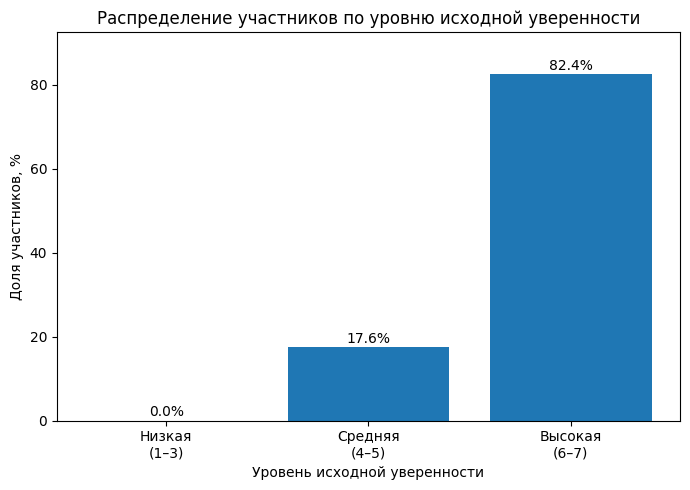

In [30]:
# Распределение участников по уровню исходной уверенности в моральных решениях
bins = [0, 3, 5, 7]
labels = ['Низкая\n(1–3)', 'Средняя\n(4–5)', 'Высокая\n(6–7)']

confidence_groups = pd.cut(
    df['conf_before_mean_all'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

confidence_percent = confidence_groups.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 5))
plt.bar(confidence_percent.index.astype(str), confidence_percent.values)
plt.ylabel('Доля участников, %')
plt.xlabel('Уровень исходной уверенности')
plt.title('Распределение участников по уровню исходной уверенности')
plt.ylim(0, max(confidence_percent.values) + 10)

for i, value in enumerate(confidence_percent.values):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.tight_layout()
plt.show()
